In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [ ]:
df = pd.read_csv("netflix_titles.csv")

In [ ]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
df.shape

(8807, 12)

In [ ]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [ ]:
df['country'] = df['country'].fillna('Unknown')

df['director'] = df['director'].fillna('Unknown')

df['cast'] = df['cast'].fillna('Unknown')

In [ ]:
df['type'].value_counts()

,count
type,
Movie,6131
TV Show,2676


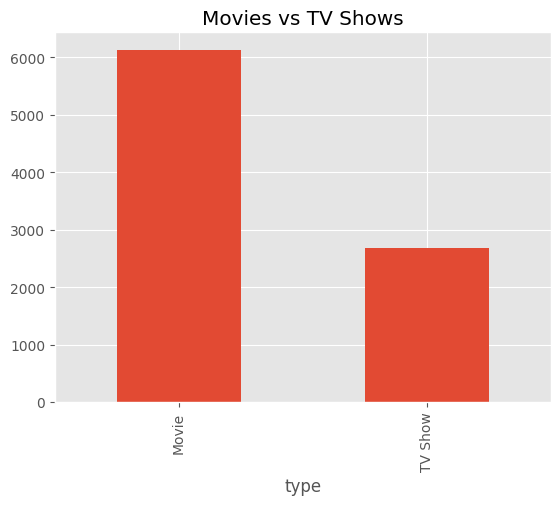

In [ ]:
df['type'].value_counts().plot(kind='bar')

plt.title("Movies vs TV Shows")
plt.savefig("movies_vs_tv.png", bbox_inches='tight')

plt.show()

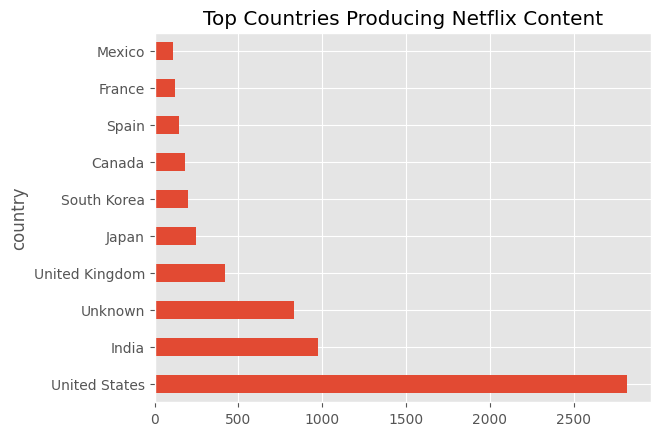

In [ ]:
country = df['country'].value_counts().head(10)

country.plot(kind='barh')

plt.title("Top Countries Producing Netflix Content")
plt.savefig("top_countries.png", bbox_inches='tight')

plt.show()

In [ ]:
# Remove extra spaces
df['date_added'] = df['date_added'].str.strip()

In [ ]:
# Convert to datetime
df['date_added'] = pd.to_datetime(
    df['date_added'],
    errors='coerce'
)


In [ ]:
# Extract year and month
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month_name()

In [ ]:
year_data = df['year_added'].value_counts().sort_index()

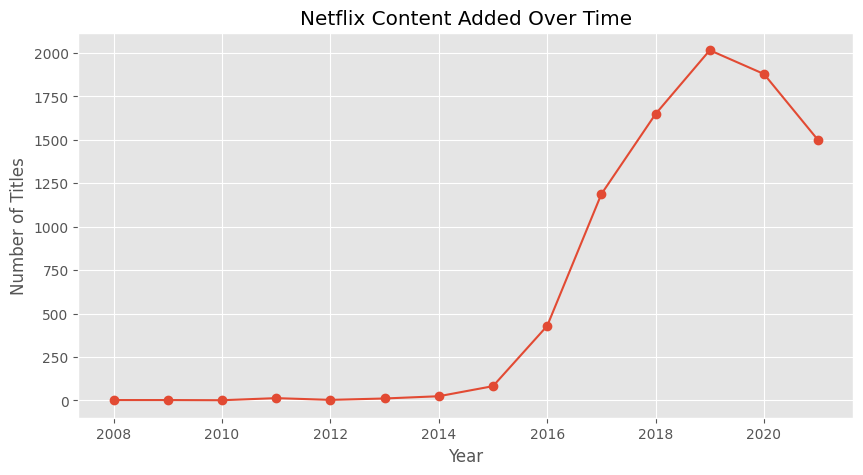

In [ ]:
plt.figure(figsize=(10,5))

year_data.plot(kind='line', marker='o')

plt.title('Netflix Content Added Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Titles')

plt.grid(True)
plt.savefig("growth_over_time.png", bbox_inches='tight')

plt.show()

Netflix witnessed rapid content growth after 2016, with a significant increase in titles added annually.


In [ ]:
genre = df['listed_in'].str.split(', ').explode()

In [ ]:
genre.value_counts().head(10)

,count
listed_in,
International Movies,2752
Dramas,2427
Comedies,1674
International TV Shows,1351
Documentaries,869
Action & Adventure,859
TV Dramas,763
Independent Movies,756
Children & Family Movies,641


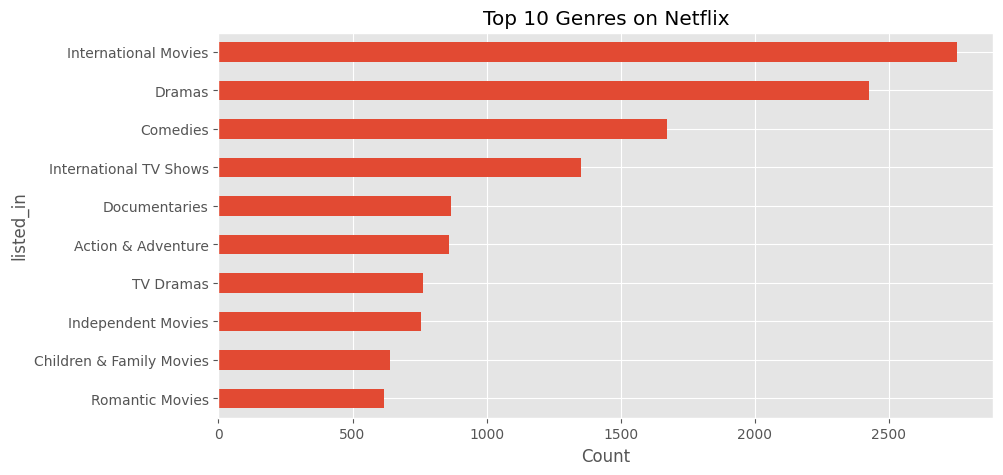

In [ ]:
plt.figure(figsize=(10,5))

genre.value_counts().head(10).sort_values().plot(kind='barh')

plt.title('Top 10 Genres on Netflix')
plt.xlabel('Count')
plt.savefig("genres.png", bbox_inches='tight')

plt.show()

Drama and International Movies are among the most common genres available on Netflix.

In [ ]:
df['rating'].value_counts()

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


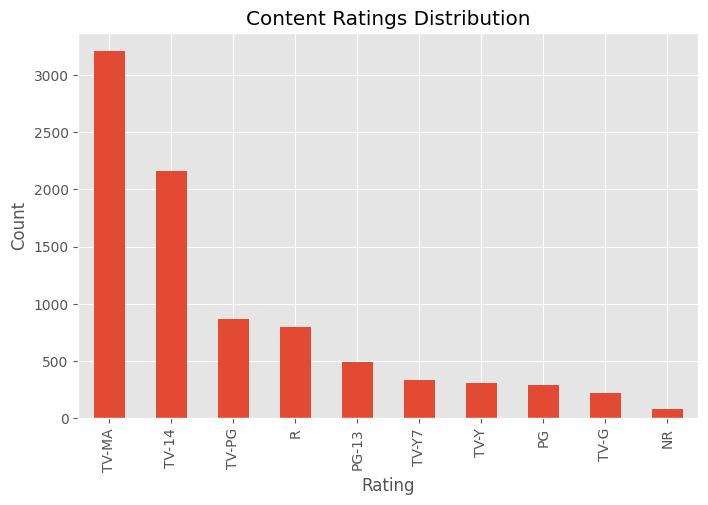

In [ ]:
plt.figure(figsize=(8,5))

df['rating'].value_counts().head(10).plot(kind='bar')

plt.title('Content Ratings Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.savefig("ratings.png", bbox_inches='tight')

plt.show()

TV-MA is the most frequently occurring content rating, indicating a strong presence of mature content.

In [ ]:
df['director'].value_counts().head(10)

,count
director,
Unknown,2634
Rajiv Chilaka,19
"Raúl Campos, Jan Suter",18
Suhas Kadav,16
Marcus Raboy,16
Jay Karas,14
Cathy Garcia-Molina,13
Martin Scorsese,12
Youssef Chahine,12


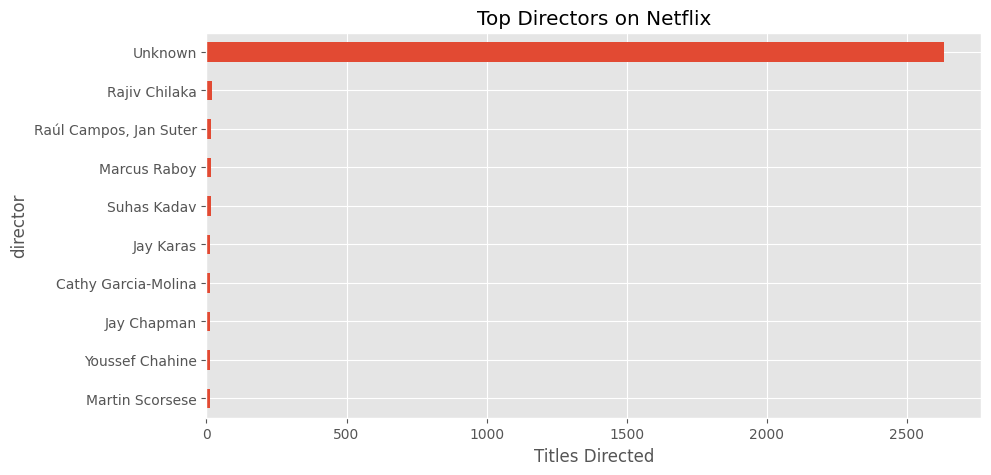

In [ ]:
plt.figure(figsize=(10,5))

df['director'].value_counts().head(10).sort_values().plot(kind='barh')

plt.title('Top Directors on Netflix')
plt.xlabel('Titles Directed')
plt.savefig("top_Directors.png", bbox_inches='tight')

plt.show()

A small number of directors contribute multiple titles to Netflix's content library.

In [ ]:
month_order = [
    'January',
    'February',
    'March',
    'April',
    'May',
    'June',
    'July',
    'August',
    'September',
    'October',
    'November',
    'December'
]

In [ ]:
monthly = df['month_added'].value_counts().reindex(month_order)

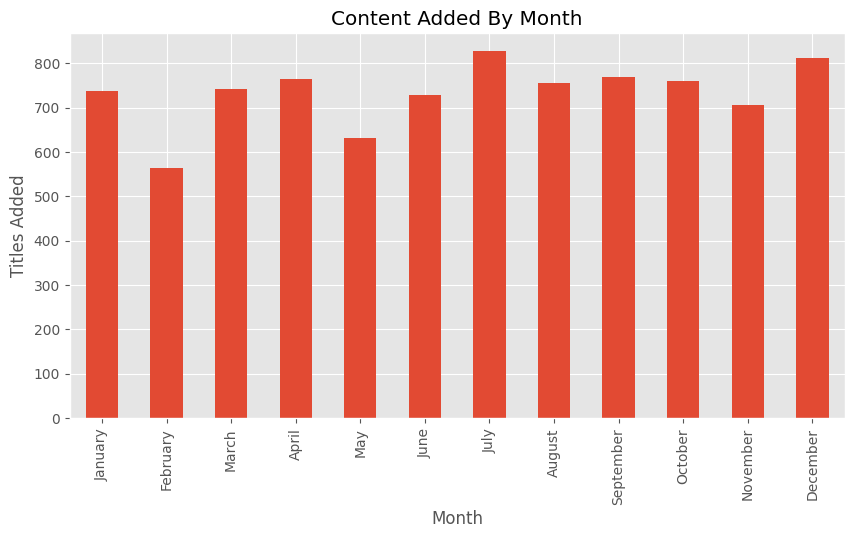

In [ ]:
plt.figure(figsize=(10,5))

monthly.plot(kind='bar')

plt.title('Content Added By Month')
plt.xlabel('Month')
plt.ylabel('Titles Added')
plt.savefig("Monthly_content.png", bbox_inches='tight')

plt.show()

Certain months show significantly higher content additions, indicating seasonal release patterns.

In [ ]:
growth = pd.crosstab(
    df['year_added'],
    df['type']
)

In [ ]:
growth.head()

type,Movie,TV Show
year_added,,
2008.0,1,1
2009.0,2,0
2010.0,1,0
2011.0,13,0
2012.0,3,0


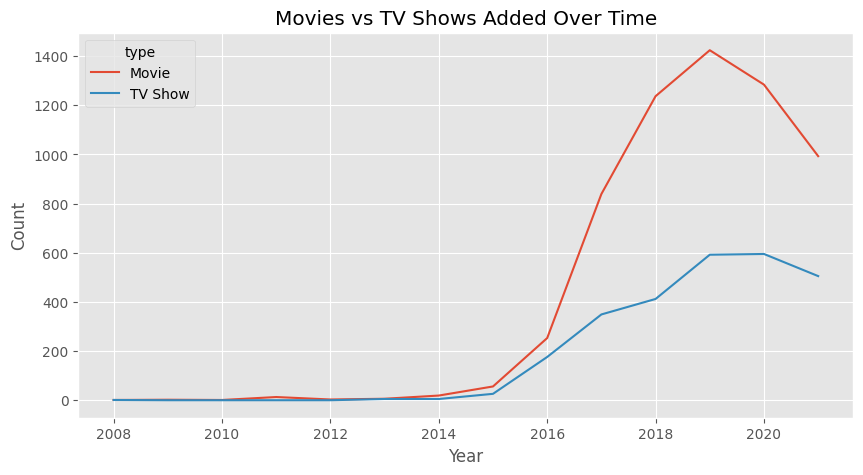

In [ ]:
growth.plot(figsize=(10,5))

plt.title('Movies vs TV Shows Added Over Time')

plt.xlabel('Year')
plt.ylabel('Count')

plt.show()

In [ ]:
release_year = df['release_year'].value_counts().head(10)

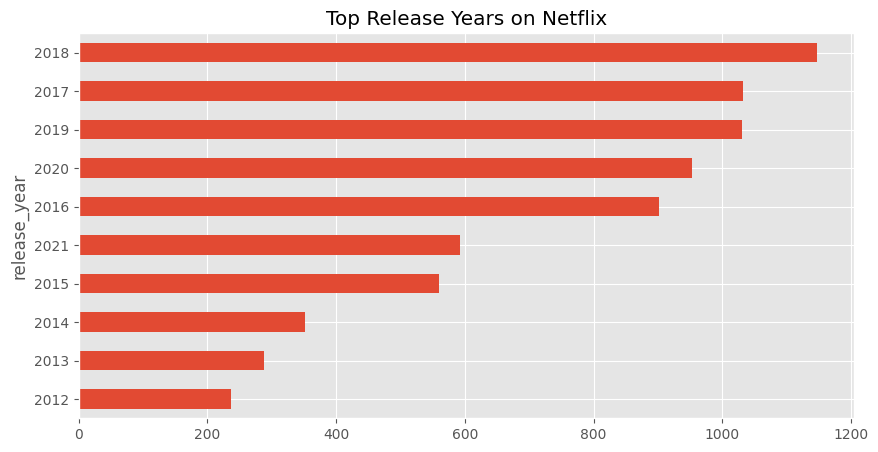

In [ ]:
plt.figure(figsize=(10,5))

release_year.sort_values().plot(kind='barh')

plt.title('Top Release Years on Netflix')

plt.show()

# Executive Summary

1. Movies dominate Netflix's content catalog.

2. The United States contributes the highest number of titles.

3. Netflix experienced rapid growth after 2016.

4. Drama and International Movies are the most common genres.

5. TV-MA is the most common rating category.

6. Content additions peak during specific months, indicating strategic release schedules.